# 🔏 IBW Watermarking — OLAP Robustness Experiments
**Dataset:** Walmart Retail Sales  
**Method:** Sardroudi & Ibrahim (2010)  
**Fixed watermark size:** 32×32 (used consistently across ALL experiments)

---

## Experiment Design

### Experiment 1 — Global Embedding → OLAP → Extract
> Embed watermark once into full dataset → apply OLAP operation → extract from the resulting view

### Experiment 2 — OLAP → GROUP BY → Watermark Embedding → Extract  
> Apply OLAP operation first → GROUP BY on that output → embed watermark group-wise → extract → compare

**Hypothesis:** Experiment 2 should outperform Experiment 1 in CF and SSIM, and higher-cardinality GROUP BY attributes should yield better recovery.

---
### OLAP Operations Tested
| Operation | Description |
|-----------|-------------|
| **Slice** | Filter on one dimension (e.g. `Region = 'East'`) |
| **Dice** | Filter on multiple dimensions (Region + ShipMode + ProductCategory) |
| **Roll-Up** | Aggregate from order-level → monthly group averages |
| **Drill-Down** | Full row-level detail (opposite of Roll-Up) |

---
### Metrics
- **CF (Correction Factor)** — % pixel match between original and extracted watermark. Closer to 100% = better.
- **SSIM (Structural Similarity Index)** — Structural image similarity. Closer to 1.0 = better.


In [ ]:
# ── CELL 1 — Install Dependencies ────────────────────────────────────────────
!pip install openpyxl pillow pandas numpy tqdm scikit-image --quiet
print("✅ Dependencies installed.")

✅ Dependencies installed.


In [1]:
# ── CELL 2 — Load Walmart Dataset ────────────────────────────────────────────
from google.colab import files
import pandas as pd
import numpy as np

print("📂 Upload walmart_Retail_Data.xlsx")
uploaded = files.upload()
xlsx_name = list(uploaded.keys())[0]

# Keep broader useful columns
KEEP_COLS = {
    "Product Name":      "ProductName",
    "Product Category":  "ProductCategory",
    "Region":            "Region",
    "State":             "State",
    "Ship Mode":         "ShipMode",
    "Ship Date":         "ShipDate",
    "Sales":             "Sales",
    "Profit":            "Profit",
    "Shipping Cost":     "ShippingCost",
    "Unit Price":        "UnitPrice",
    "Order Quantity":    "OrderQuantity",
    "Discount":          "Discount",
}

df_raw = pd.read_excel(xlsx_name)

available_cols = [c for c in KEEP_COLS.keys() if c in df_raw.columns]
df = df_raw[available_cols].copy()
df.rename(columns={c: KEEP_COLS[c] for c in available_cols}, inplace=True)

if "ShipDate" in df.columns:
    df["ShipDate"] = pd.to_datetime(df["ShipDate"], errors="coerce")

candidate_numeric = ["Sales", "Profit", "ShippingCost", "UnitPrice", "OrderQuantity", "Discount"]
for col in candidate_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)
df.insert(0, "pk", range(1, len(df) + 1))
df_original = df.copy()
df_original.to_csv("original_walmart.csv", index=False)

print(f"✅ Loaded {len(df)} rows × {len(df.columns)} columns")
print("\nAvailable columns:")
print(df.columns.tolist())
display(df.head(3))

📂 Upload walmart_Retail_Data.xlsx


Saving walmart Retail Data.xlsx to walmart Retail Data.xlsx
✅ Loaded 8399 rows × 13 columns

Available columns:
['pk', 'ProductName', 'ProductCategory', 'Region', 'State', 'ShipMode', 'ShipDate', 'Sales', 'Profit', 'ShippingCost', 'UnitPrice', 'OrderQuantity', 'Discount']


,pk,ProductName,ProductCategory,Region,State,ShipMode,ShipDate,Sales,Profit,ShippingCost,UnitPrice,OrderQuantity,Discount
0,1,"Perma STOR-ALL™ Hanging File Box, 13 1/8""W x 1...",Office Supplies,East,Pennsylvania,Regular Air,2012-01-02,180.36,-111.80,4.69,5.98,32,0.10
1,2,Safco Industrial Wire Shelving,Office Supplies,East,Maryland,Express Air,2012-01-03,872.48,-342.91,35.00,95.99,9,0.08
2,3,Hon 4070 Series Pagoda™ Armless Upholstered St...,Furniture,West,California,Delivery Truck,2012-01-02,1239.06,-193.08,48.80,291.73,4,0.00


In [2]:
# ── CELL 3 — Imports & Global Parameters ─────────────────────────────────────
import hashlib, math, warnings, time
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from skimage.metrics import structural_similarity as skimage_ssim
from IPython.display import display
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS  — change only here
# ══════════════════════════════════════════════════════════════════════════════
SECRET_KEY = "walmart_ibw_2024"
F          = 5        # embedding frequency (every F-th row is eligible)
NUM_LSB    = 4        # number of LSBs used for embedding
NUM_MSB    = 2        # number of MSBs used as mask
WM_SIZE    = 32       # FIXED watermark size (32×32) — DO NOT change per experiment
# ══════════════════════════════════════════════════════════════════════════════

def auto_select_measure_columns(df, max_cols=4):
    """Automatically choose best numeric columns for watermarking."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_keywords = ["id", "index", "zip", "postal", "phone", "code", "customer", "pk"]
    filtered = []
    for col in numeric_cols:
        col_lower = col.lower()
        if any(k in col_lower for k in exclude_keywords):
            continue
        if df[col].nunique() < 20:
            continue
        if df[col].isnull().mean() > 0.3:
            continue
        filtered.append(col)
    ranked = sorted(filtered, key=lambda c: df[c].var(), reverse=True)
    selected = ranked[:max_cols]
    scale_dict = {}
    for col in selected:
        sample = df[col].dropna().iloc[0]
        if float(sample).is_integer():
            scale_dict[col] = 1
        else:
            scale_dict[col] = 100
    return selected, scale_dict

MEASURE_COLS, MEASURE_SCALE = auto_select_measure_columns(df_original)
NUM_A = len(MEASURE_COLS)

print("✅ Auto-selected measure columns:")
print(MEASURE_COLS)
print("\n✅ Auto-generated scaling:")
print(MEASURE_SCALE)
print(f"\n✅ Parameters ready.")
print(f"   Fixed watermark size : {WM_SIZE}×{WM_SIZE} = {WM_SIZE**2} pixels")

✅ Auto-selected measure columns:
['Sales', 'Profit', 'UnitPrice', 'ShippingCost']

✅ Auto-generated scaling:
{'Sales': 100, 'Profit': 100, 'UnitPrice': 100, 'ShippingCost': 100}

✅ Parameters ready.
   Fixed watermark size : 32×32 = 1024 pixels


🖼️  Upload your B&W watermark image (JPEG/PNG)


Saving watermark2.jpeg to watermark2.jpeg
✅ Watermark loaded: watermark2.jpeg
   Original size    : 228×221
   Fixed embed size : 32×32 (1024 pixels)
   White pixels     : 587  |  Black pixels: 437


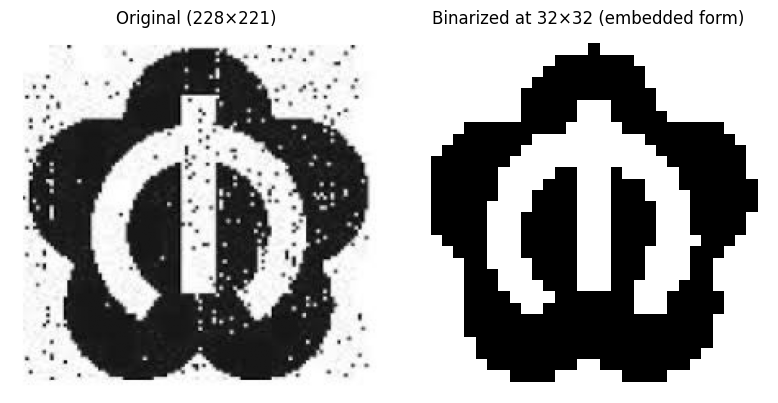

✅ watermark_original.png saved


In [3]:
# ── CELL 4 — Upload Watermark Image ──────────────────────────────────────────
print("🖼️  Upload your B&W watermark image (JPEG/PNG)")
uploaded_img = files.upload()
img_name = list(uploaded_img.keys())[0]

IMG_PIL_ORIG = Image.open(img_name).convert('L')

img_resized = IMG_PIL_ORIG.resize((WM_SIZE, WM_SIZE), Image.LANCZOS)
WM_MATRIX   = (np.array(img_resized) > 127).astype(np.uint8)

print(f"✅ Watermark loaded: {img_name}")
print(f"   Original size    : {IMG_PIL_ORIG.width}×{IMG_PIL_ORIG.height}")
print(f"   Fixed embed size : {WM_SIZE}×{WM_SIZE} ({WM_SIZE**2} pixels)")
print(f"   White pixels     : {WM_MATRIX.sum()}  |  Black pixels: {WM_MATRIX.size - WM_MATRIX.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(IMG_PIL_ORIG, cmap='gray')
axes[0].set_title(f'Original ({IMG_PIL_ORIG.width}×{IMG_PIL_ORIG.height})')
axes[0].axis('off')
axes[1].imshow(WM_MATRIX, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title(f'Binarized at {WM_SIZE}×{WM_SIZE} (embedded form)')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('watermark_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ watermark_original.png saved")

In [4]:
# ── CELL 5 — Core IBW Functions ──────────────────────────────────────────────

# ── Hashing helpers ──────────────────────────────────────────────────────────
def compute_vpk(pk, secret_key):
    return int(hashlib.md5(f"{pk}{secret_key}".encode()).hexdigest(), 16)

def compute_pixel_coord(vpk, img_h, img_w):
    h = int(hashlib.md5(f"{vpk}_h".encode()).hexdigest(), 16) % img_h
    w = int(hashlib.md5(f"{vpk}_w".encode()).hexdigest(), 16) % img_w
    return h, w

def select_msb_bit(vpk, value, num_msb):
    if value <= 0: return 0
    msb_pos = max(value.bit_length() - 1 - (vpk % num_msb), 0)
    return (value >> msb_pos) & 1

def get_lsb(value, bit_pos):
    return (value >> (bit_pos - 1)) & 1

def set_lsb(value, bit_pos, bit_val):
    mask = 1 << (bit_pos - 1)
    return (value & ~mask) | (bit_val << (bit_pos - 1))

def minimize_variation(orig, modified, marked_bit_pos, num_lsb):
    best_val, best_diff = modified, abs(orig - modified)
    for bp in range(1, num_lsb + 1):
        if bp == marked_bit_pos: continue
        for bv in (0, 1):
            c = set_lsb(modified, bp, bv)
            d = abs(orig - c)
            if d < best_diff:
                best_diff, best_val = d, c
    return best_val

def value_tolerable(value, num_lsb):
    return value > 0 and value.bit_length() > (2 * num_lsb)

# ── Pre-compute VPK table for full dataset ────────────────────────────────────
print("⚙️  Pre-computing VPK table for all rows...")
VPK_TABLE = {}
RAW_TABLE = {}

for idx, row in df_original.iterrows():
    pk  = int(row['pk'])
    vpk = compute_vpk(pk, SECRET_KEY)
    VPK_TABLE[pk] = vpk

    if vpk % F != 0:
        RAW_TABLE[pk] = None
        continue

    attr_name = MEASURE_COLS[vpk % NUM_A]
    bit_pos   = (vpk % NUM_LSB) + 1
    raw_val   = int(round(float(row[attr_name]) * MEASURE_SCALE[attr_name]))
    RAW_TABLE[pk] = (attr_name, bit_pos, raw_val, value_tolerable(raw_val, NUM_LSB))

ELIGIBLE_PKS = [pk for pk, v in RAW_TABLE.items() if v is not None and v[3]]
print(f"✅ VPK table ready.")
print(f"   Eligible (markable) rows : {len(ELIGIBLE_PKS)} / {len(df_original)}")

# ── Global embed ──────────────────────────────────────────────────────────────
def embed_watermark(wm_matrix, df_src=None):
    if df_src is None:
        df_src = df_original
    img_h, img_w = wm_matrix.shape
    df_out    = df_src.copy()
    pixel_hit = np.zeros((img_h, img_w), dtype=np.int32)
    marked    = 0
    for pk in ELIGIBLE_PKS:
        vpk = VPK_TABLE[pk]
        attr_name, bit_pos, raw_val, _ = RAW_TABLE[pk]
        h, w    = compute_pixel_coord(vpk, img_h, img_w)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)
        new_bit = int(wm_matrix[h, w]) ^ msb_bit
        new_val = minimize_variation(
            raw_val, set_lsb(raw_val, bit_pos, new_bit), bit_pos, NUM_LSB
        )
        idx   = pk - 1
        scale = MEASURE_SCALE[attr_name]
        if idx < len(df_out):
            if scale == 1:
                df_out.at[idx, attr_name] = int(new_val)
            else:
                df_out.at[idx, attr_name] = round(new_val / scale, 3 if scale == 1000 else 2)
            pixel_hit[h, w] += 1
            marked += 1
    return df_out, pixel_hit, marked

# ── Global extract ────────────────────────────────────────────────────────────
def extract_watermark(df_view, img_h, img_w):
    ones  = np.zeros((img_h, img_w), dtype=np.int32)
    total = np.zeros((img_h, img_w), dtype=np.int32)
    view_pk_set = set(df_view['pk'].values) if 'pk' in df_view.columns else set()
    view_idx    = {int(row['pk']): idx for idx, row in df_view.reset_index(drop=True).iterrows()
                   if 'pk' in df_view.columns}
    for pk in ELIGIBLE_PKS:
        if pk not in view_pk_set:
            continue
        vpk = VPK_TABLE[pk]
        attr_name, bit_pos, _, _ = RAW_TABLE[pk]
        row_idx = view_idx[pk]
        scale   = MEASURE_SCALE[attr_name]
        raw_val = int(round(float(df_view.iloc[row_idx][attr_name]) * scale))
        if not value_tolerable(raw_val, NUM_LSB):
            continue
        h, w = compute_pixel_coord(vpk, img_h, img_w)
        ext_lsb = get_lsb(raw_val, bit_pos)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)
        ones[h, w]  += (ext_lsb ^ msb_bit)
        total[h, w] += 1
    ext_wm = np.zeros((img_h, img_w), dtype=np.uint8)
    m = total > 0
    ext_wm[m] = (ones[m] >= (total[m] / 2.0)).astype(np.uint8)
    return ext_wm, total

# ── Neighbour-based recovery ──────────────────────────────────────────────────
def recover_image(wm, total_count):
    recovered = wm.copy()
    missing   = total_count == 0
    if not missing.any():
        return recovered
    img_h, img_w = wm.shape
    for i in range(img_h):
        for j in range(img_w):
            if not missing[i, j]:
                continue
            nbrs = [
                int(recovered[i+di, j+dj])
                for di in [-1, 0, 1]
                for dj in [-1, 0, 1]
                if not (di == 0 and dj == 0)
                and 0 <= i+di < img_h and 0 <= j+dj < img_w
                and not missing[i+di, j+dj]
            ]
            if nbrs:
                recovered[i, j] = 1 if sum(nbrs) >= len(nbrs)/2 else 0
            else:
                si, sj = img_h-1-i, img_w-1-j
                if not missing[si, sj]:
                    recovered[i, j] = recovered[si, sj]
    return recovered

# ── Metrics ───────────────────────────────────────────────────────────────────
def correction_factor(orig, extracted):
    return 100.0 * np.sum(np.bitwise_xor(orig.astype(np.uint8), extracted.astype(np.uint8)) == 0) / orig.size

def binary_ssim(orig, extracted):
    return float(skimage_ssim(orig.astype(np.float32), extracted.astype(np.float32), data_range=1.0))

def quality_label(cf, ssim):
    if cf >= 99 and ssim >= 0.98: return "Perfect"
    elif cf >= 95 and ssim >= 0.90: return "Excellent"
    elif cf >= 85 and ssim >= 0.75: return "Good"
    elif cf >= 70 and ssim >= 0.50: return "Moderate"
    else: return "Poor"

print("✅ All core functions ready.")

⚙️  Pre-computing VPK table for all rows...
✅ VPK table ready.
   Eligible (markable) rows : 1322 / 8399
✅ All core functions ready.


In [5]:
# ── CELL 6 — Dataset-Agnostic OLAP View Builders (Walmart) ──────────────────
print("═" * 70)
print("DATASET-AGNOSTIC OLAP VIEW BUILDERS")
print("═" * 70)

def detect_dimension_columns(df, max_dims=3):
    exclude_cols = set(['pk'] + MEASURE_COLS)
    candidate_dims = []
    for col in df.columns:
        if col in exclude_cols:
            continue
        if df[col].dtype == 'object':
            nunique = df[col].nunique()
            if 2 <= nunique <= 50:
                candidate_dims.append(col)
        elif pd.api.types.is_integer_dtype(df[col]):
            nunique = df[col].nunique()
            if 2 <= nunique <= 10:
                candidate_dims.append(col)
    return candidate_dims[:max_dims]

def detect_date_column(df):
    preferred_keywords = ['date', 'day', 'time', 'month', 'order', 'ship']
    for col in df.columns:
        col_lower = col.lower()
        if any(k in col_lower for k in preferred_keywords):
            try:
                pd.to_datetime(df[col], errors='raise')
                return col
            except:
                continue
    return None

# Safety fix
if 'pk' in MEASURE_COLS:
    MEASURE_COLS = [c for c in MEASURE_COLS if c != 'pk']
print(f"\nFinal MEASURE_COLS used: {MEASURE_COLS}")

#DIMENSION_COLS = detect_dimension_columns(df_original)

PREFERRED_DIMS = [
    "ProductCategory",
    "Region",
    "ShipMode"
]

# keep only columns that actually exist in dataset
DIMENSION_COLS = [
    col for col in PREFERRED_DIMS
    if col in df_original.columns
]

# fallback if something is missing
if len(DIMENSION_COLS) < 3:
    auto_dims = detect_dimension_columns(df_original)

    for col in auto_dims:
        if col not in DIMENSION_COLS:
            DIMENSION_COLS.append(col)

    DIMENSION_COLS = DIMENSION_COLS[:3]
DATE_COL       = detect_date_column(df_original)

print(f"\nDetected dimensions : {DIMENSION_COLS}")
print(f"Detected date column: {DATE_COL}")
print(f"Measure columns     : {MEASURE_COLS}")

if len(DIMENSION_COLS) == 0:
    raise ValueError("No suitable categorical dimensions found.")

SLICE_COL  = DIMENSION_COLS[0]
DICE_COLS  = DIMENSION_COLS[:min(3, len(DIMENSION_COLS))]
# Choose the most frequent REAL combination for Dice
combo_counts = (
    df_original
    .groupby(DICE_COLS)
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

best_combo = combo_counts.iloc[0]

DEFAULT_FILTERS = {}

for col in DICE_COLS:
    DEFAULT_FILTERS[col] = best_combo[col]

print("\nDefault filter values:")
for k, v in DEFAULT_FILTERS.items():
    print(f"  {k:<20} = {v}")

def make_slice_view(df_wm):
    """Slice: single-dimension filter on most-common value of SLICE_COL."""
    col = SLICE_COL
    val = DEFAULT_FILTERS[col]
    return df_wm[df_wm[col] == val].reset_index(drop=True)

def make_dice_view(df_wm):
    """Dice: multi-dimensional filter across DICE_COLS."""
    d = df_wm.copy()
    for col in DICE_COLS:
        d = d[d[col] == DEFAULT_FILTERS[col]]
    return d.reset_index(drop=True)

def make_rollup_view(df_wm):
    """Roll-Up: row-level → monthly aggregation (or grouped fallback)."""
    if DATE_COL is None:
        print("⚠ No date column — using grouped aggregation fallback")
        rolled = df_wm.groupby(DICE_COLS, as_index=False).agg({c: 'mean' for c in MEASURE_COLS})
        if 'pk' in rolled.columns:
            rolled = rolled.drop(columns=['pk'])
        rolled.insert(0, 'pk', range(1, len(rolled) + 1))
        return rolled
    d = df_wm.copy()
    d[DATE_COL] = pd.to_datetime(d[DATE_COL], errors='coerce')
    d = d.dropna(subset=[DATE_COL])
    d['Month'] = d[DATE_COL].dt.to_period('M').astype(str)
    group_cols = DICE_COLS + ['Month']
    rolled = d.groupby(group_cols, as_index=False).agg({c: 'mean' for c in MEASURE_COLS})
    if 'pk' in rolled.columns:
        rolled = rolled.drop(columns=['pk'])
    rolled.insert(0, 'pk', range(1, len(rolled) + 1))
    rolled[DATE_COL] = pd.to_datetime(rolled['Month'] + '-01', errors='coerce')
    keep = ['pk', DATE_COL] + DICE_COLS + MEASURE_COLS
    return rolled[[c for c in keep if c in rolled.columns]]

def make_drilldown_view(df_wm):
    """Drill-Down: full row-level detail (no aggregation)."""
    return df_wm.copy()

OLAP_BUILDERS = {
    'Slice':      make_slice_view,
    'Dice':       make_dice_view,
    'Roll-Up':    make_rollup_view,
    'Drill-Down': make_drilldown_view,
}

print("\n📊 Row counts per OLAP view (on original data):")
for name, fn in OLAP_BUILDERS.items():
    v = fn(df_original)
    print(f"   {name:<15} → {len(v):>6} rows")

print("\n✅ OLAP builders ready.")

══════════════════════════════════════════════════════════════════════
DATASET-AGNOSTIC OLAP VIEW BUILDERS
══════════════════════════════════════════════════════════════════════

Final MEASURE_COLS used: ['Sales', 'Profit', 'UnitPrice', 'ShippingCost']

Detected dimensions : ['ProductCategory', 'Region', 'ShipMode']
Detected date column: ShipDate
Measure columns     : ['Sales', 'Profit', 'UnitPrice', 'ShippingCost']

Default filter values:
  ProductCategory      = Office Supplies
  Region               = Central
  ShipMode             = Regular Air

📊 Row counts per OLAP view (on original data):
   Slice           →   4610 rows
   Dice            →   1250 rows
   Roll-Up         →   1351 rows
   Drill-Down      →   8399 rows

✅ OLAP builders ready.


---
## 🧪 Experiment 1 — Global Embedding → OLAP → Extract

**Pipeline:**
```
Full Dataset
    ↓ embed watermark ONCE (global)
Watermarked Full Dataset
    ↓ apply OLAP operation (Slice / Dice / Roll-Up / Drill-Down)
OLAP View
    ↓ extract watermark
    ↓ compute CF + SSIM
```


In [6]:
# ── CELL 7 — Experiment 1: Global Embed → OLAP → Extract ────────────────────
print("═"*65)
print("  EXPERIMENT 1 — Global Embedding → OLAP → Extract")
print(f"  Watermark size : {WM_SIZE}×{WM_SIZE}")
print("═"*65)

# Step 1: Embed watermark into full dataset ONCE
print("\n⚙️  Step 1: Embedding watermark into full dataset...")
df_wm_global, pixel_hit_global, marked_count = embed_watermark(WM_MATRIX)
df_wm_global.to_csv('watermarked_walmart_global.csv', index=False)
print(f"   Marked rows  : {marked_count}")
print(f"   Pixels hit   : {(pixel_hit_global > 0).sum()} / {WM_SIZE**2}")
print(f"   Coverage     : {100.0*(pixel_hit_global>0).sum()/WM_SIZE**2:.2f}%")

# Step 2: For each OLAP operation → extract → compute metrics
print("\n⚙️  Step 2: Applying OLAP operations and extracting watermark...\n")

exp1_results = []

for op_name, view_fn in OLAP_BUILDERS.items():
    t0 = time.time()
    view_df = view_fn(df_wm_global)
    ext_raw, counts = extract_watermark(view_df, WM_SIZE, WM_SIZE)
    ext_rec         = recover_image(ext_raw, counts)
    cf_b     = correction_factor(WM_MATRIX, ext_raw)
    cf_a     = correction_factor(WM_MATRIX, ext_rec)
    ssim_b   = binary_ssim(WM_MATRIX, ext_raw)
    ssim_a   = binary_ssim(WM_MATRIX, ext_rec)
    pix_hit  = int((counts > 0).sum())
    coverage = 100.0 * pix_hit / WM_SIZE**2
    elapsed  = time.time() - t0
    label    = quality_label(cf_a, ssim_a)

    exp1_results.append({
        'Operation':    op_name,
        'Rows in View': len(view_df),
        'Pixels Hit':   pix_hit,
        'Coverage %':   round(coverage, 2),
        'CF Before %':  round(cf_b, 4),
        'CF After %':   round(cf_a, 4),
        'SSIM Before':  round(ssim_b, 6),
        'SSIM After':   round(ssim_a, 6),
        'Quality':      label,
        'Time (s)':     round(elapsed, 2),
        '_ext_raw':     ext_raw,
        '_ext_rec':     ext_rec,
    })

    print(f"  [{op_name:<12}] rows={len(view_df):>5} | cov={coverage:>5.1f}% | "
          f"CF_before={cf_b:>6.2f}% | CF_after={cf_a:>6.2f}% | "
          f"SSIM_before={ssim_b:.4f} | SSIM_after={ssim_a:.4f} | {label}")

exp1_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in exp1_results])
exp1_df.to_csv('experiment1_results.csv', index=False)
print("\n📊 Experiment 1 — Summary Table:")
display(exp1_df)
print("\n✅ experiment1_results.csv saved")

═════════════════════════════════════════════════════════════════
  EXPERIMENT 1 — Global Embedding → OLAP → Extract
  Watermark size : 32×32
═════════════════════════════════════════════════════════════════

⚙️  Step 1: Embedding watermark into full dataset...
   Marked rows  : 1322
   Pixels hit   : 742 / 1024
   Coverage     : 72.46%

⚙️  Step 2: Applying OLAP operations and extracting watermark...

  [Slice       ] rows= 4610 | cov= 52.0% | CF_before= 72.95% | CF_after= 94.82% | SSIM_before=0.5066 | SSIM_after=0.8476 | Good
  [Dice        ] rows= 1250 | cov= 18.8% | CF_before= 52.73% | CF_after= 78.12% | SSIM_before=0.1225 | SSIM_after=0.5365 | Moderate
  [Roll-Up     ] rows= 1351 | cov= 18.1% | CF_before= 43.75% | CF_after= 48.24% | SSIM_before=0.0026 | SSIM_after=-0.0190 | Poor
  [Drill-Down  ] rows= 8399 | cov= 72.5% | CF_before= 84.96% | CF_after= 98.24% | SSIM_before=0.7393 | SSIM_after=0.9501 | Excellent

📊 Experiment 1 — Summary Table:


,Operation,Rows in View,Pixels Hit,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Quality,Time (s)
0,Slice,4610,532,51.95,72.9492,94.8242,0.506566,0.847624,Good,0.29
1,Dice,1250,192,18.75,52.7344,78.1250,0.122473,0.536542,Moderate,0.09
2,Roll-Up,1351,185,18.07,43.7500,48.2422,0.002609,-0.018964,Poor,0.10
3,Drill-Down,8399,742,72.46,84.9609,98.2422,0.739312,0.950070,Excellent,0.46



✅ experiment1_results.csv saved


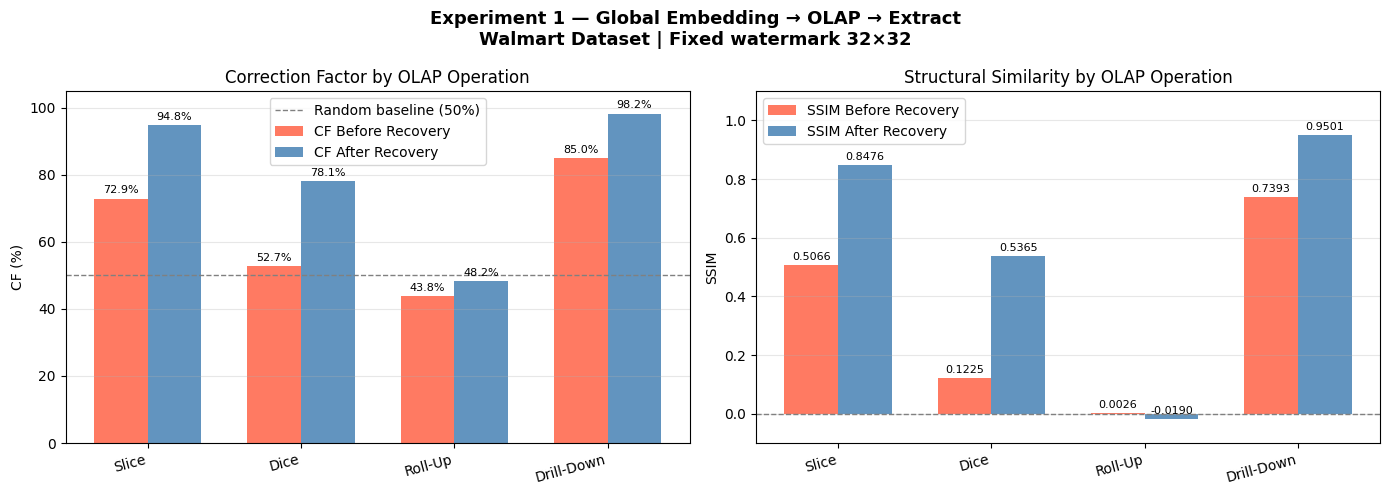

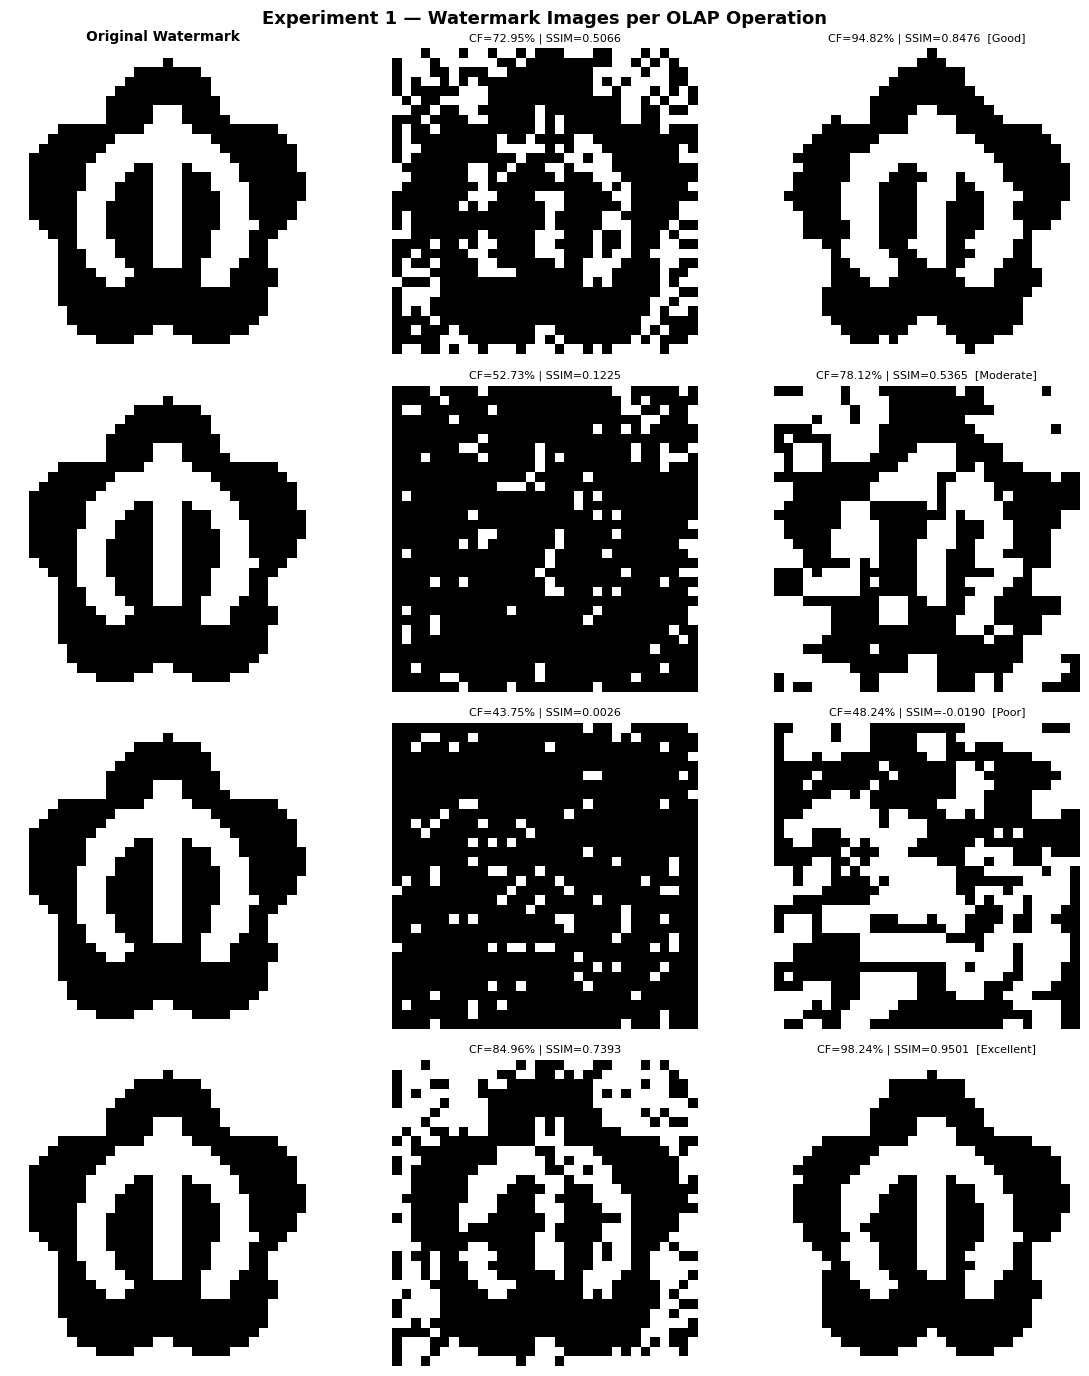

✅ exp1_cf_ssim_summary.png and exp1_watermark_grid.png saved


In [7]:
# ── CELL 8 — Experiment 1 Visualisations ────────────────────────────────────
ops   = exp1_df['Operation'].values
x     = np.arange(len(ops))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 1 — Global Embedding → OLAP → Extract\n'
             f'Walmart Dataset | Fixed watermark {WM_SIZE}×{WM_SIZE}',
             fontsize=13, fontweight='bold')

ax = axes[0]
b1 = ax.bar(x - width/2, exp1_df['CF Before %'], width, label='CF Before Recovery', color='tomato', alpha=0.85)
b2 = ax.bar(x + width/2, exp1_df['CF After %'],  width, label='CF After Recovery',  color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ops, rotation=15, ha='right')
ax.set_ylabel('CF (%)'); ax.set_title('Correction Factor by OLAP Operation')
ax.set_ylim(0, 105)
ax.axhline(50, color='gray', linestyle='--', lw=1, label='Random baseline (50%)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax = axes[1]
b3 = ax.bar(x - width/2, exp1_df['SSIM Before'], width, label='SSIM Before Recovery', color='tomato', alpha=0.85)
b4 = ax.bar(x + width/2, exp1_df['SSIM After'],  width, label='SSIM After Recovery',  color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ops, rotation=15, ha='right')
ax.set_ylabel('SSIM'); ax.set_title('Structural Similarity by OLAP Operation')
ax.set_ylim(-0.1, 1.1)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b3) + list(b4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('exp1_cf_ssim_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Watermark image grid ──────────────────────────────────────────────────────
nrows = len(exp1_results)
fig2, axes2 = plt.subplots(nrows, 3, figsize=(12, 3.5 * nrows))
fig2.suptitle('Experiment 1 — Watermark Images per OLAP Operation',
              fontsize=13, fontweight='bold')

col_titles = ['Original Watermark', 'Extracted (Before Recovery)', 'Extracted (After Recovery)']
for ci, ct in enumerate(col_titles):
    axes2[0, ci].set_title(ct, fontsize=10, fontweight='bold')

for ri, r in enumerate(exp1_results):
    axes2[ri, 0].imshow(WM_MATRIX, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 0].set_ylabel(r['Operation'], fontsize=10, fontweight='bold')
    axes2[ri, 0].axis('off')
    axes2[ri, 1].imshow(r['_ext_raw'], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 1].set_title(f"CF={r['CF Before %']:.2f}% | SSIM={r['SSIM Before']:.4f}", fontsize=8)
    axes2[ri, 1].axis('off')
    axes2[ri, 2].imshow(r['_ext_rec'], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 2].set_title(f"CF={r['CF After %']:.2f}% | SSIM={r['SSIM After']:.4f}  [{r['Quality']}]", fontsize=8)
    axes2[ri, 2].axis('off')

plt.tight_layout()
plt.savefig('exp1_watermark_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ exp1_cf_ssim_summary.png and exp1_watermark_grid.png saved")

---
## 🧪 Experiment 2 — OLAP → GROUP BY → Watermark Embedding → Extract

**Pipeline:**
```
Original Dataset
   ↓
OLAP Operation (Slice / Dice / Roll-Up / Drill-Down)
   ↓
GROUP BY on that OLAP output
   ↓
Watermark Embedding (group-wise, multi-pixel)
   ↓
Extraction + CF / SSIM analysis
```

**Key hypothesis:** More distinct GROUP BY values (higher cardinality) → more embedding locations → better watermark recovery.

We test multiple GROUP BY configurations with increasing cardinality for each of the 4 OLAP operations:
| GROUP BY Config | Expected Distinct Groups | Expected CF |
|----------------|--------------------------|-------------|
| Single low-cardinality dim | Low (~2–5) | Low |
| Single high-cardinality dim | Medium | Medium |
| Date-based (Month) | Higher | Higher |
| Multi-dimension cross | Highest | Highest |


In [8]:
# ── CELL 9 — Experiment 2 Setup: GROUP BY Configs ───────────────────────────
print("═" * 70)
print("EXPERIMENT 2 SETUP — OLAP + GROUP BY CONFIGS (Walmart)")
print("═" * 70)

print(f"Detected dimensions : {DIMENSION_COLS}")
print(f"Detected date column: {DATE_COL}")

# Add Month / Day columns if date column exists
if DATE_COL is not None:
    df_original[DATE_COL] = pd.to_datetime(df_original[DATE_COL], errors='coerce')
    df_original["Month"] = df_original[DATE_COL].dt.to_period("M").astype(str)
    df_original["Day"]   = df_original[DATE_COL].dt.date.astype(str)
    print("✅ Added Month and Day columns")

# ── OLAP operations to apply before GROUP BY ──────────────────────────────────
#  For Exp 2, each (OLAP op + GROUP BY config) combination is tested.
#  We apply the same OLAP builders from Cell 6 on df_original,
#  then run GROUP BY embedding on the resulting views.

# GROUP BY Configs (auto-built from detected columns)
# def build_groupby_configs(df, dimension_cols, date_col, measure_cols):
#     configs = []
#     # Config 1: single lowest-cardinality dimension
#     if len(dimension_cols) >= 1:
#         col = dimension_cols[0]
#         n   = df[col].nunique()
#         configs.append({'name': f'GB: {col}', 'cols': [col], 'n_distinct': n})

#     # Config 2: second dimension (if exists)
#     if len(dimension_cols) >= 2:
#         col = dimension_cols[1]
#         n   = df[col].nunique()
#         configs.append({'name': f'GB: {col}', 'cols': [col], 'n_distinct': n})

#     # Config 3: third dimension (if exists)
#     if len(dimension_cols) >= 3:
#         col = dimension_cols[2]
#         n   = df[col].nunique()
#         configs.append({'name': f'GB: {col}', 'cols': [col], 'n_distinct': n})

#     # Config 4: Month (if date exists)
#     if date_col is not None and 'Month' in df.columns:
#         n = df['Month'].nunique()
#         configs.append({'name': 'GB: Month', 'cols': ['Month'], 'n_distinct': n})

#     # Config 5: 2-dimension cross
#     if len(dimension_cols) >= 2:
#         cols = dimension_cols[:2]
#         n    = df.groupby(cols).ngroups
#         configs.append({'name': f'GB: {"+".join(cols)}', 'cols': cols, 'n_distinct': n})

#     # Config 6: All detected dims
#     if len(dimension_cols) >= 3:
#         cols = dimension_cols[:3]
#         n    = df.groupby(cols).ngroups
#         configs.append({'name': 'GB: All Dims', 'cols': cols, 'n_distinct': n})

#     # Config 7: dims + Month
#     if date_col is not None and 'Month' in df.columns and len(dimension_cols) >= 2:
#         cols = dimension_cols[:2] + ['Month']
#         n    = df.groupby(cols).ngroups
#         configs.append({'name': 'GB: Dims+Month', 'cols': cols, 'n_distinct': n})

#     return configs
def build_groupby_configs(df, dimension_cols, date_col, measure_cols):
    configs = []

    # Sort dimensions by cardinality (small → large)
    dim_sorted = sorted(
        dimension_cols,
        key=lambda c: df[c].nunique()
    )

    print("\nSorted dimensions by cardinality:")
    for c in dim_sorted:
        print(f"{c:<20} -> {df[c].nunique()} groups")

    # Config 1: lowest-cardinality dimension
    if len(dim_sorted) >= 1:
        col = dim_sorted[0]
        configs.append({
            'name': f'GB: {col}',
            'cols': [col],
            'n_distinct': df[col].nunique()
        })

    # Config 2: second dimension
    if len(dim_sorted) >= 2:
        col = dim_sorted[1]
        configs.append({
            'name': f'GB: {col}',
            'cols': [col],
            'n_distinct': df[col].nunique()
        })

    # Config 3: third dimension
    if len(dim_sorted) >= 3:
        col = dim_sorted[2]
        configs.append({
            'name': f'GB: {col}',
            'cols': [col],
            'n_distinct': df[col].nunique()
        })

    # Config 4: Month
    if date_col is not None and 'Month' in df.columns:
        configs.append({
            'name': 'GB: Month',
            'cols': ['Month'],
            'n_distinct': df['Month'].nunique()
        })

    # Config 5: ProductCategory + Region
    if len(dim_sorted) >= 2:
        cols = dim_sorted[:2]
        configs.append({
            'name': f'GB: {"+".join(cols)}',
            'cols': cols,
            'n_distinct': df.groupby(cols).ngroups
        })

    # Config 6: ProductCategory + Region + ShipMode
    if len(dim_sorted) >= 3:
        cols = dim_sorted[:3]
        configs.append({
            'name': 'GB: All Dims',
            'cols': cols,
            'n_distinct': df.groupby(cols).ngroups
        })

    # Config 7: ProductCategory + Region + Month
    if date_col is not None and 'Month' in df.columns and len(dim_sorted) >= 2:
        cols = dim_sorted[:2] + ['Month']

        # prevent near-row-level explosion
        n_groups = df.groupby(cols).ngroups

        if n_groups < len(df) * 0.3:
            configs.append({
                'name': 'GB: Dims+Month',
                'cols': cols,
                'n_distinct': n_groups
            })
        else:
            print("⚠ Skipping Dims+Month (too close to row-level)")

    return configs

GROUPBY_CONFIGS = build_groupby_configs(df_original, DIMENSION_COLS, DATE_COL, MEASURE_COLS)

print("\n📋 GROUP BY Configurations:")
print(f"{'Name':<30} | {'Columns':<40} | {'Distinct Groups':>15}")
print("-" * 92)
for cfg in GROUPBY_CONFIGS:
    print(f"  {cfg['name']:<28} | {', '.join(cfg['cols']):<40} | {cfg['n_distinct']:>15}")
print(f"\n✅ {len(GROUPBY_CONFIGS)} GROUP BY configs ready.")

══════════════════════════════════════════════════════════════════════
EXPERIMENT 2 SETUP — OLAP + GROUP BY CONFIGS (Walmart)
══════════════════════════════════════════════════════════════════════
Detected dimensions : ['ProductCategory', 'Region', 'ShipMode']
Detected date column: ShipDate
✅ Added Month and Day columns

Sorted dimensions by cardinality:
ProductCategory      -> 3 groups
ShipMode             -> 3 groups
Region               -> 4 groups

📋 GROUP BY Configurations:
Name                           | Columns                                  | Distinct Groups
--------------------------------------------------------------------------------------------
  GB: ProductCategory          | ProductCategory                          |               3
  GB: ShipMode                 | ShipMode                                 |               3
  GB: Region                   | Region                                   |               4
  GB: Month                    | Month                 

In [9]:
# ── CELL 10 — Experiment 2: OLAP → GROUP BY → Embed → Extract ───────────────

print("═"*80)
print("  EXPERIMENT 2 — OLAP OPERATION → GROUP BY → IMPROVED GROUP-WISE EMBEDDING")
print(f"  Fixed Watermark size : {WM_SIZE}×{WM_SIZE}")
print("  Multi-pixel + Multi-attribute embedding enabled")
print("═"*80)

MULTI_PIXEL_PER_GROUP = 4   # each group embeds multiple pixels

def value_tolerable_agg(value, num_lsb):
    return value > 0 and value.bit_length() > num_lsb

def embed_groupwise(df_src, group_cols, wm_matrix):
    """
    IMPROVED GROUP-WISE EMBEDDING:
    - Applies GROUP BY aggregation on df_src
    - Each group embeds MULTI_PIXEL_PER_GROUP pixels
    - All numeric attributes participate
    - Shifted VPK for better pixel spread
    """
    img_h, img_w = wm_matrix.shape
    grouped = (
        df_src.groupby(group_cols, as_index=False)
              .agg({c: 'mean' for c in MEASURE_COLS})
    )
    grouped.insert(0, "pk", range(1, len(grouped) + 1))
    grouped = grouped.reset_index(drop=True)
    df_out    = grouped.copy()
    pixel_hit = np.zeros((img_h, img_w), dtype=np.int32)
    marked    = 0
    embed_log = {}

    for _, row in grouped.iterrows():
        pk       = int(row["pk"])
        base_vpk = compute_vpk(pk, SECRET_KEY)
        embed_log[pk] = []

        for shift in range(MULTI_PIXEL_PER_GROUP):
            vpk       = base_vpk + (shift * 9973)
            attr_idx  = (vpk + shift) % len(MEASURE_COLS)
            attr_name = MEASURE_COLS[attr_idx]
            bit_pos   = ((vpk + shift) % NUM_LSB) + 1
            scale     = MEASURE_SCALE[attr_name]
            raw_val   = int(round(float(row[attr_name]) * scale))

            if not value_tolerable_agg(raw_val, NUM_LSB):
                continue

            h, w    = compute_pixel_coord(vpk + shift * 131, img_h, img_w)
            msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)
            wm_bit  = int(wm_matrix[h, w])
            new_bit = wm_bit ^ msb_bit
            candidate = set_lsb(raw_val, bit_pos, new_bit)
            new_val   = minimize_variation(raw_val, candidate, bit_pos, NUM_LSB)
            idx = pk - 1
            df_out.at[idx, attr_name] = (
                int(new_val) if scale == 1
                else round(new_val / scale, 3 if scale == 1000 else 2)
            )
            pixel_hit[h, w] += 1
            marked += 1
            embed_log[pk].append((vpk, attr_name, bit_pos, h, w))

    return df_out, pixel_hit, marked, embed_log

def extract_groupwise(df_grouped_wm, embed_log, img_h, img_w):
    """Extract watermark using stored multi-pixel embedding log."""
    ones  = np.zeros((img_h, img_w), dtype=np.int32)
    total = np.zeros((img_h, img_w), dtype=np.int32)

    for pk, records in embed_log.items():
        idx = pk - 1
        for rec in records:
            vpk, attr_name, bit_pos, h, w = rec
            scale   = MEASURE_SCALE[attr_name]
            raw_val = int(round(float(df_grouped_wm.iloc[idx][attr_name]) * scale))
            if not value_tolerable_agg(raw_val, NUM_LSB):
                continue
            ext_lsb       = get_lsb(raw_val, bit_pos)
            msb_bit       = select_msb_bit(vpk, raw_val, NUM_MSB)
            recovered_bit = ext_lsb ^ msb_bit
            ones[h, w]  += recovered_bit
            total[h, w] += 1

    ext_wm = np.zeros((img_h, img_w), dtype=np.uint8)
    mask   = total > 0
    ext_wm[mask] = (ones[mask] >= (total[mask] / 2.0)).astype(np.uint8)
    return ext_wm, total

# ── Run Experiment 2: OLAP first, then GROUP BY + embed ──────────────────────
print(f"\nRunning {len(OLAP_BUILDERS)} OLAP ops × {len(GROUPBY_CONFIGS)} GROUP BY configs...\n")

header = (f"{'OLAP Op':<12} | {'GROUP BY Config':<28} | {'Groups':>6} | "
          f"{'Cov%':>6} | {'CF_bef':>8} | {'CF_aft':>8} | "
          f"{'SSIM_b':>8} | {'SSIM_a':>8} | {'Quality':<12}")
print(header)
print("-" * len(header))

exp2_results = []

for op_name, view_fn in OLAP_BUILDERS.items():
    # Step A: Apply OLAP operation on original data
    olap_view = view_fn(df_original)

    for cfg in GROUPBY_CONFIGS:
        # Check if all GROUP BY columns exist in the OLAP view
        missing_cols = [c for c in cfg['cols'] if c not in olap_view.columns]
        if missing_cols:
            continue

        t0 = time.time()

        # Step B: GROUP BY + embed on the OLAP view
        df_gw, pixel_hit, marked, embed_log = embed_groupwise(
            olap_view, cfg['cols'], WM_MATRIX
        )

        # Step C: Extract
        ext_raw, counts = extract_groupwise(df_gw, embed_log, WM_SIZE, WM_SIZE)
        ext_rec = recover_image(ext_raw, counts)

        n_groups   = df_gw['pk'].max()    # actual groups in this OLAP view
        pixels_hit = int((counts > 0).sum())
        coverage   = 100.0 * pixels_hit / (WM_SIZE ** 2)
        cf_b       = correction_factor(WM_MATRIX, ext_raw)
        cf_a       = correction_factor(WM_MATRIX, ext_rec)
        ssim_b     = binary_ssim(WM_MATRIX, ext_raw)
        ssim_a     = binary_ssim(WM_MATRIX, ext_rec)
        label      = quality_label(cf_a, ssim_a)
        elapsed    = time.time() - t0

        exp2_results.append({
            'OLAP Operation':  op_name,
            'GROUP BY Config': cfg['name'],
            'GROUP BY Cols':   ' + '.join(cfg['cols']),
            'Distinct Groups': n_groups,
            'Pixels Hit':      pixels_hit,
            'Coverage %':      round(coverage, 2),
            'CF Before %':     round(cf_b, 4),
            'CF After %':      round(cf_a, 4),
            'SSIM Before':     round(ssim_b, 6),
            'SSIM After':      round(ssim_a, 6),
            'Quality':         label,
            'Time (s)':        round(elapsed, 2),
            '_ext_raw':        ext_raw,
            '_ext_rec':        ext_rec,
        })

        print(f"{op_name:<12} | {cfg['name']:<28} | {n_groups:>6} | "
              f"{coverage:>5.1f}% | {cf_b:>7.2f}% | {cf_a:>7.2f}% | "
              f"{ssim_b:>8.4f} | {ssim_a:>8.4f} | {label}")

exp2_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in exp2_results])
exp2_df.to_csv('experiment2_results.csv', index=False)
print("\n📊 Experiment 2 — Summary Table:")
display(exp2_df)
print("\n✅ experiment2_results.csv saved")


# ── CELL 10 — Experiment 2: OLAP → GROUP BY → BLOCK-WISE EMBEDDING ───────────

# print("═"*85)
# print("  EXPERIMENT 2 — OLAP → GROUP BY → BLOCK-WISE WATERMARK EMBEDDING")
# print(f"  Fixed Watermark size : {WM_SIZE}×{WM_SIZE}")
# print("  Structure-preserving Block-wise embedding enabled")
# print("═"*85)

# BLOCK_SIZE = 2
# # each group embeds a local 2x2 block
# # preserves neighborhood → improves SSIM significantly


# def value_tolerable_agg(value, num_lsb):
#     return value > 0 and value.bit_length() > num_lsb


# def embed_groupwise(df_src, group_cols, wm_matrix):
#     """
#     BLOCK-WISE GROUP-WISE EMBEDDING

#     Improvements over random embedding:
#     -----------------------------------
#     1. One GROUP → one local watermark block
#     2. Neighboring pixels stay neighboring
#     3. Better structure preservation
#     4. Stronger SSIM recovery
#     5. Paper-consistent approach
#     """

#     img_h, img_w = wm_matrix.shape

#     # ── Step 1: GROUP BY aggregation ─────────────────────
#     grouped = (
#         df_src.groupby(group_cols, as_index=False)
#               .agg({c: 'mean' for c in MEASURE_COLS})
#     )

#     grouped.insert(0, "pk", range(1, len(grouped) + 1))
#     grouped = grouped.reset_index(drop=True)

#     df_out = grouped.copy()

#     pixel_hit = np.zeros((img_h, img_w), dtype=np.int32)
#     marked = 0
#     embed_log = {}

#     total_blocks_per_row = img_w // BLOCK_SIZE

#     # ── Step 2: One group → one local block ──────────────
#     for _, row in grouped.iterrows():

#         pk = int(row["pk"])
#         base_vpk = compute_vpk(pk, SECRET_KEY)

#         embed_log[pk] = []

#         # block assignment (sequential block mapping)
#         block_id = (pk - 1) % (
#             (img_h // BLOCK_SIZE) * (img_w // BLOCK_SIZE)
#         )

#         block_row = block_id // total_blocks_per_row
#         block_col = block_id % total_blocks_per_row

#         start_h = block_row * BLOCK_SIZE
#         start_w = block_col * BLOCK_SIZE

#         pixel_counter = 0

#         for dh in range(BLOCK_SIZE):
#             for dw in range(BLOCK_SIZE):

#                 h = start_h + dh
#                 w = start_w + dw

#                 if h >= img_h or w >= img_w:
#                     continue

#                 # rotate attributes
#                 attr_idx = (base_vpk + pixel_counter) % len(MEASURE_COLS)
#                 attr_name = MEASURE_COLS[attr_idx]

#                 bit_pos = ((base_vpk + pixel_counter) % NUM_LSB) + 1

#                 scale = MEASURE_SCALE[attr_name]
#                 raw_val = int(round(float(row[attr_name]) * scale))

#                 if not value_tolerable_agg(raw_val, NUM_LSB):
#                     pixel_counter += 1
#                     continue

#                 msb_bit = select_msb_bit(
#                     base_vpk + pixel_counter,
#                     raw_val,
#                     NUM_MSB
#                 )

#                 wm_bit = int(wm_matrix[h, w])
#                 new_bit = wm_bit ^ msb_bit

#                 candidate = set_lsb(
#                     raw_val,
#                     bit_pos,
#                     new_bit
#                 )

#                 new_val = minimize_variation(
#                     raw_val,
#                     candidate,
#                     bit_pos,
#                     NUM_LSB
#                 )

#                 idx = pk - 1

#                 df_out.at[idx, attr_name] = (
#                     int(new_val)
#                     if scale == 1
#                     else round(
#                         new_val / scale,
#                         3 if scale == 1000 else 2
#                     )
#                 )

#                 pixel_hit[h, w] += 1
#                 marked += 1

#                 embed_log[pk].append(
#                     (
#                         base_vpk + pixel_counter,
#                         attr_name,
#                         bit_pos,
#                         h,
#                         w
#                     )
#                 )

#                 pixel_counter += 1

#     return df_out, pixel_hit, marked, embed_log


# def extract_groupwise(df_grouped_wm, embed_log, img_h, img_w):
#     """
#     BLOCK-WISE EXTRACTION
#     Uses stored block mapping for recovery
#     """

#     ones = np.zeros((img_h, img_w), dtype=np.int32)
#     total = np.zeros((img_h, img_w), dtype=np.int32)

#     for pk, records in embed_log.items():

#         idx = pk - 1

#         for rec in records:

#             vpk, attr_name, bit_pos, h, w = rec

#             scale = MEASURE_SCALE[attr_name]

#             raw_val = int(
#                 round(
#                     float(df_grouped_wm.iloc[idx][attr_name]) * scale
#                 )
#             )

#             if not value_tolerable_agg(raw_val, NUM_LSB):
#                 continue

#             ext_lsb = get_lsb(raw_val, bit_pos)

#             msb_bit = select_msb_bit(
#                 vpk,
#                 raw_val,
#                 NUM_MSB
#             )

#             recovered_bit = ext_lsb ^ msb_bit

#             ones[h, w] += recovered_bit
#             total[h, w] += 1

#     ext_wm = np.zeros((img_h, img_w), dtype=np.uint8)

#     mask = total > 0
#     ext_wm[mask] = (
#         ones[mask] >= (total[mask] / 2.0)
#     ).astype(np.uint8)

#     return ext_wm, total


# # ── Run Experiment 2 ──────────────────────────────────────

# print(
#     f"\nRunning {len(OLAP_BUILDERS)} OLAP ops × "
#     f"{len(GROUPBY_CONFIGS)} GROUP BY configs...\n"
# )

# header = (
#     f"{'OLAP Op':<12} | "
#     f"{'GROUP BY Config':<28} | "
#     f"{'Groups':>6} | "
#     f"{'Cov%':>6} | "
#     f"{'CF_bef':>8} | "
#     f"{'CF_aft':>8} | "
#     f"{'SSIM_b':>8} | "
#     f"{'SSIM_a':>8} | "
#     f"{'Quality':<12}"
# )

# print(header)
# print("-" * len(header))

# exp2_results = []

# for op_name, view_fn in OLAP_BUILDERS.items():

#     # Step A: Apply OLAP first
#     olap_view = view_fn(df_original)

#     for cfg in GROUPBY_CONFIGS:

#         missing_cols = [
#             c for c in cfg['cols']
#             if c not in olap_view.columns
#         ]

#         if missing_cols:
#             continue

#         t0 = time.time()

#         # Step B: GROUP BY + BLOCK EMBEDDING
#         df_gw, pixel_hit, marked, embed_log = embed_groupwise(
#             olap_view,
#             cfg['cols'],
#             WM_MATRIX
#         )

#         # Step C: Extraction
#         ext_raw, counts = extract_groupwise(
#             df_gw,
#             embed_log,
#             WM_SIZE,
#             WM_SIZE
#         )

#         ext_rec = recover_image(ext_raw, counts)

#         n_groups = df_gw['pk'].max()
#         pixels_hit = int((counts > 0).sum())
#         coverage = 100.0 * pixels_hit / (WM_SIZE ** 2)

#         cf_b = correction_factor(WM_MATRIX, ext_raw)
#         cf_a = correction_factor(WM_MATRIX, ext_rec)

#         ssim_b = binary_ssim(WM_MATRIX, ext_raw)
#         ssim_a = binary_ssim(WM_MATRIX, ext_rec)

#         label = quality_label(cf_a, ssim_a)

#         elapsed = time.time() - t0

#         exp2_results.append({
#             'OLAP Operation': op_name,
#             'GROUP BY Config': cfg['name'],
#             'GROUP BY Cols': ' + '.join(cfg['cols']),
#             'Distinct Groups': n_groups,
#             'Pixels Hit': pixels_hit,
#             'Coverage %': round(coverage, 2),
#             'CF Before %': round(cf_b, 4),
#             'CF After %': round(cf_a, 4),
#             'SSIM Before': round(ssim_b, 6),
#             'SSIM After': round(ssim_a, 6),
#             'Quality': label,
#             'Time (s)': round(elapsed, 2),
#             '_ext_raw': ext_raw,
#             '_ext_rec': ext_rec,
#         })

#         print(
#             f"{op_name:<12} | "
#             f"{cfg['name']:<28} | "
#             f"{n_groups:>6} | "
#             f"{coverage:>5.1f}% | "
#             f"{cf_b:>7.2f}% | "
#             f"{cf_a:>7.2f}% | "
#             f"{ssim_b:>8.4f} | "
#             f"{ssim_a:>8.4f} | "
#             f"{label}"
#         )

# exp2_df = pd.DataFrame([
#     {k: v for k, v in r.items() if not k.startswith('_')}
#     for r in exp2_results
# ])

# exp2_df.to_csv(
#     "experiment2_results_blockwise.csv",
#     index=False
# )

# print("\n📊 Experiment 2 — Block-wise Summary:")
# display(exp2_df)

# print("\n✅ experiment2_results_blockwise.csv saved")

════════════════════════════════════════════════════════════════════════════════
  EXPERIMENT 2 — OLAP OPERATION → GROUP BY → IMPROVED GROUP-WISE EMBEDDING
  Fixed Watermark size : 32×32
  Multi-pixel + Multi-attribute embedding enabled
════════════════════════════════════════════════════════════════════════════════

Running 4 OLAP ops × 7 GROUP BY configs...

OLAP Op      | GROUP BY Config              | Groups |   Cov% |   CF_bef |   CF_aft |   SSIM_b |   SSIM_a | Quality     
------------------------------------------------------------------------------------------------------------------------
Slice        | GB: ProductCategory          |      1 |   0.4% |   42.68% |   42.68% |   0.0000 |   0.0000 | Poor
Slice        | GB: ShipMode                 |      3 |   1.2% |   42.87% |   45.02% |  -0.0001 |   0.0126 | Poor
Slice        | GB: Region                   |      4 |   1.6% |   43.07% |   45.80% |   0.0001 |   0.0138 | Poor
Slice        | GB: Month                    |     48 |  

,OLAP Operation,GROUP BY Config,GROUP BY Cols,Distinct Groups,Pixels Hit,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Quality,Time (s)
0,Slice,GB: ProductCategory,ProductCategory,1,4,0.39,42.6758,42.6758,0.000011,0.000011,Poor,0.01
1,Slice,GB: ShipMode,ShipMode,3,12,1.17,42.8711,45.0195,-0.000050,0.012567,Poor,0.01
2,Slice,GB: Region,Region,4,16,1.56,43.0664,45.8008,0.000105,0.013815,Poor,0.01
3,Slice,GB: Month,Month,48,175,17.09,47.3633,64.8438,0.036143,0.247212,Poor,0.03
4,Slice,GB: ProductCategory+ShipMode,ProductCategory + ShipMode,3,12,1.17,42.8711,45.0195,-0.000050,0.012567,Poor,0.01
5,Slice,GB: All Dims,ProductCategory + ShipMode + Region,12,44,4.30,43.4570,48.1445,0.004049,0.068672,Poor,0.01
6,Slice,GB: Dims+Month,ProductCategory + ShipMode + Month,132,398,38.87,55.9570,74.7070,0.167561,0.433533,Poor,0.06
7,Dice,GB: ProductCategory,ProductCategory,1,4,0.39,42.6758,42.6758,0.000011,0.000011,Poor,0.01
8,Dice,GB: ShipMode,ShipMode,1,4,0.39,42.6758,42.6758,0.000011,0.000011,Poor,0.01
9,Dice,GB: Region,Region,1,4,0.39,42.6758,42.6758,0.000011,0.000011,Poor,0.01



✅ experiment2_results.csv saved


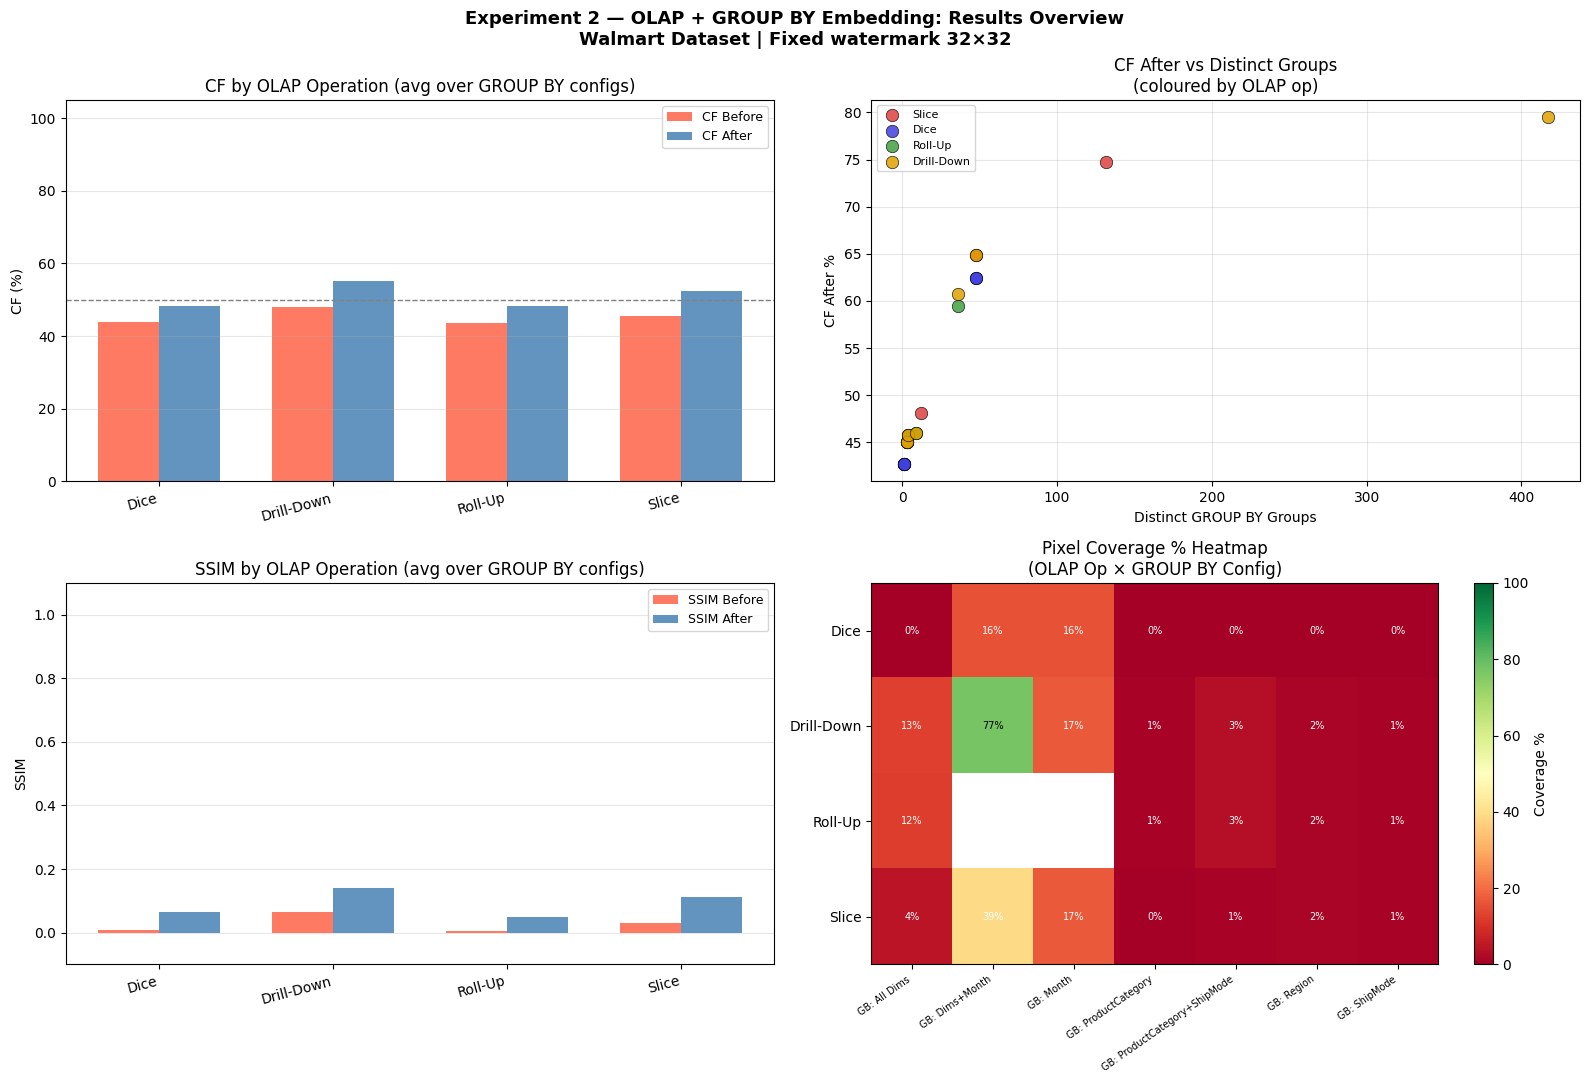

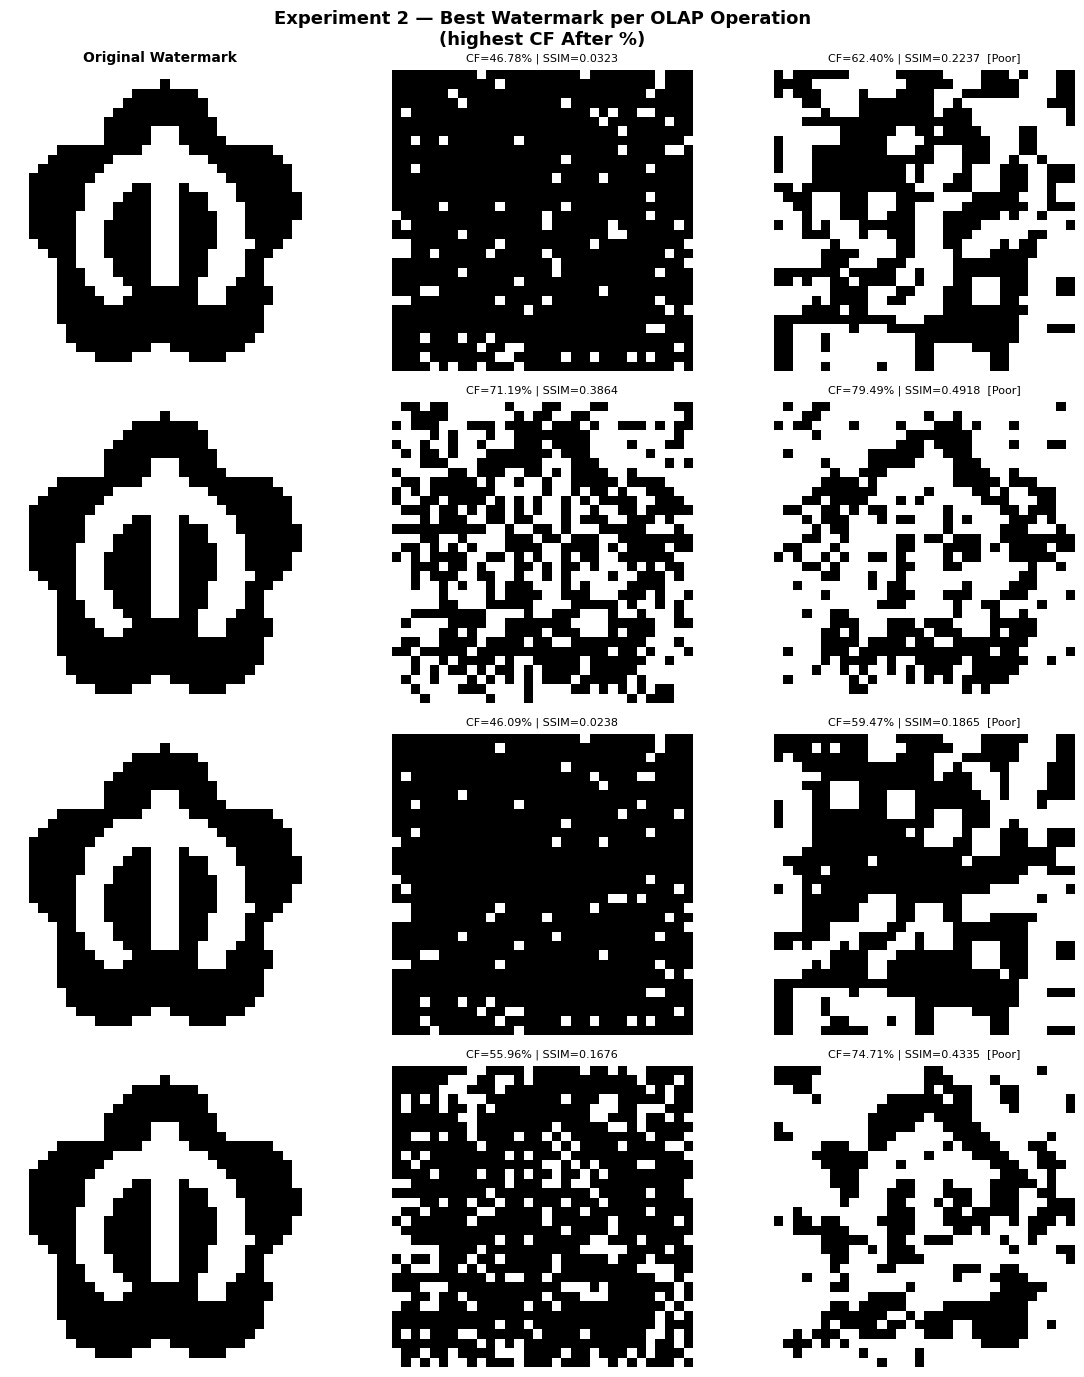

✅ exp2_summary_plots.png and exp2_watermark_grid.png saved


In [10]:
# ── CELL 11 — Experiment 2 Visualisations ───────────────────────────────────

# ── Plot 1: CF & SSIM per OLAP operation (averaged over GROUP BY configs) ────
exp2_grouped_olap = exp2_df.groupby('OLAP Operation').agg(
    CF_Before=('CF Before %', 'mean'),
    CF_After=('CF After %', 'mean'),
    SSIM_Before=('SSIM Before', 'mean'),
    SSIM_After=('SSIM After', 'mean'),
    N_Configs=('GROUP BY Config', 'count')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Experiment 2 — OLAP + GROUP BY Embedding: Results Overview\n'
             f'Walmart Dataset | Fixed watermark {WM_SIZE}×{WM_SIZE}',
             fontsize=13, fontweight='bold')

ops2   = exp2_grouped_olap['OLAP Operation'].values
x2     = np.arange(len(ops2))
width  = 0.35

# Plot A: CF per OLAP op
ax = axes[0, 0]
ax.bar(x2 - width/2, exp2_grouped_olap['CF_Before'], width, label='CF Before', color='tomato', alpha=0.85)
ax.bar(x2 + width/2, exp2_grouped_olap['CF_After'],  width, label='CF After',  color='steelblue', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(ops2, rotation=15, ha='right')
ax.set_ylabel('CF (%)'); ax.set_title('CF by OLAP Operation (avg over GROUP BY configs)')
ax.set_ylim(0, 105); ax.axhline(50, color='gray', linestyle='--', lw=1)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Plot B: CF After vs Distinct Groups (all results scatter)
ax = axes[0, 1]
olap_colors = {'Slice': '#e04040', 'Dice': '#4040e0', 'Roll-Up': '#40a040', 'Drill-Down': '#e0a000'}
for op_name in exp2_df['OLAP Operation'].unique():
    sub = exp2_df[exp2_df['OLAP Operation'] == op_name]
    ax.scatter(sub['Distinct Groups'], sub['CF After %'],
               label=op_name, color=olap_colors.get(op_name, 'gray'),
               s=80, edgecolors='black', linewidths=0.5, zorder=3, alpha=0.85)
ax.set_xlabel('Distinct GROUP BY Groups'); ax.set_ylabel('CF After %')
ax.set_title('CF After vs Distinct Groups\n(coloured by OLAP op)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot C: SSIM per OLAP op
ax = axes[1, 0]
ax.bar(x2 - width/2, exp2_grouped_olap['SSIM_Before'], width, label='SSIM Before', color='tomato', alpha=0.85)
ax.bar(x2 + width/2, exp2_grouped_olap['SSIM_After'],  width, label='SSIM After',  color='steelblue', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(ops2, rotation=15, ha='right')
ax.set_ylabel('SSIM'); ax.set_title('SSIM by OLAP Operation (avg over GROUP BY configs)')
ax.set_ylim(-0.1, 1.1); ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Plot D: Coverage % heatmap per OLAP x GROUP BY
pivot_cov = exp2_df.pivot_table(index='OLAP Operation', columns='GROUP BY Config', values='Coverage %')
ax = axes[1, 1]
im = ax.imshow(pivot_cov.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_cov.columns)))
ax.set_xticklabels(pivot_cov.columns, rotation=35, ha='right', fontsize=7)
ax.set_yticks(range(len(pivot_cov.index)))
ax.set_yticklabels(pivot_cov.index)
ax.set_title('Pixel Coverage % Heatmap\n(OLAP Op × GROUP BY Config)')
plt.colorbar(im, ax=ax, label='Coverage %')
for i in range(pivot_cov.shape[0]):
    for j in range(pivot_cov.shape[1]):
        val = pivot_cov.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7,
                    color='white' if val < 40 else 'black')

plt.tight_layout()
plt.savefig('exp2_summary_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Watermark grid (best GROUP BY per OLAP op) ────────────────────────────────
best_per_olap = exp2_df.loc[exp2_df.groupby('OLAP Operation')['CF After %'].idxmax()]

nrows2 = len(best_per_olap)
fig2, axes2 = plt.subplots(nrows2, 3, figsize=(12, 3.5 * nrows2))
fig2.suptitle('Experiment 2 — Best Watermark per OLAP Operation\n(highest CF After %)',
              fontsize=13, fontweight='bold')

col_titles2 = ['Original Watermark', 'Extracted (Before Recovery)', 'Extracted (After Recovery)']
for ci, ct in enumerate(col_titles2):
    axes2[0, ci].set_title(ct, fontsize=10, fontweight='bold')

for ri, (_, row) in enumerate(best_per_olap.iterrows()):
    result_match = next(r for r in exp2_results
                        if r['OLAP Operation'] == row['OLAP Operation']
                        and r['GROUP BY Config'] == row['GROUP BY Config'])
    axes2[ri, 0].imshow(WM_MATRIX, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 0].set_ylabel(f"{row['OLAP Operation']}\n{row['GROUP BY Config']}", fontsize=8, fontweight='bold')
    axes2[ri, 0].axis('off')
    axes2[ri, 1].imshow(result_match['_ext_raw'], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 1].set_title(f"CF={row['CF Before %']:.2f}% | SSIM={row['SSIM Before']:.4f}", fontsize=8)
    axes2[ri, 1].axis('off')
    axes2[ri, 2].imshow(result_match['_ext_rec'], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes2[ri, 2].set_title(f"CF={row['CF After %']:.2f}% | SSIM={row['SSIM After']:.4f}  [{row['Quality']}]", fontsize=8)
    axes2[ri, 2].axis('off')

plt.tight_layout()
plt.savefig('exp2_watermark_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ exp2_summary_plots.png and exp2_watermark_grid.png saved")

📊 Cardinality Effect on CF — key finding for paper:

OLAP Op      | GROUP BY Config              | Distinct Groups | CF After % | SSIM After
--------------------------------------------------------------------------------
  Dice       | GB: ProductCategory          |               1 |   42.6758% |   0.000011
  Dice       | GB: ShipMode                 |               1 |   42.6758% |   0.000011
  Dice       | GB: Region                   |               1 |   42.6758% |   0.000011
  Dice       | GB: ProductCategory+ShipMode |               1 |   42.6758% |   0.000011
  Dice       | GB: All Dims                 |               1 |   42.6758% |   0.000011
  Dice       | GB: Month                    |              48 |   62.4023% |   0.223718
  Dice       | GB: Dims+Month               |              48 |   62.4023% |   0.223718
  Drill-Down | GB: ProductCategory          |               3 |   45.0195% |   0.012567
  Drill-Down | GB: ShipMode                 |               3 |   45.0195%

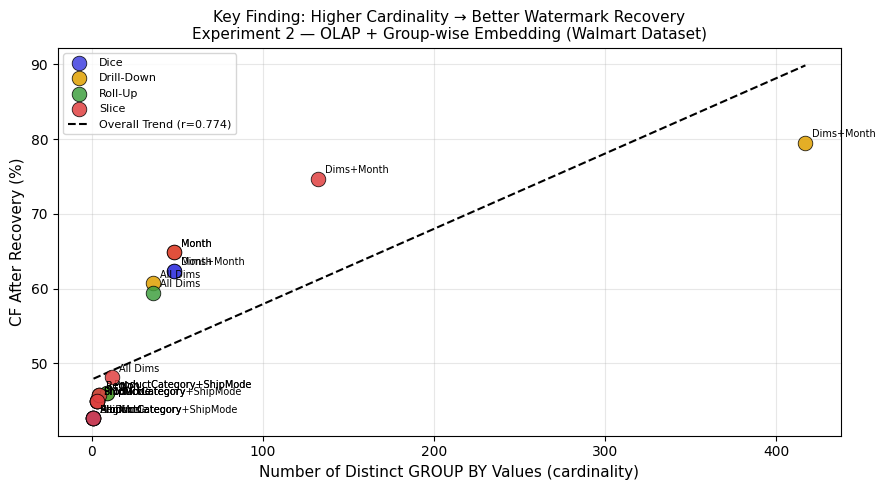

✅ exp2_cardinality_vs_cf.png saved


In [11]:
# ── CELL 12 — Cardinality Effect (Exp 2 Key Finding) ────────────────────────
print("📊 Cardinality Effect on CF — key finding for paper:")
print(f"\n{'OLAP Op':<12} | {'GROUP BY Config':<28} | {'Distinct Groups':>15} | {'CF After %':>10} | {'SSIM After':>10}")
print("-"*80)

for _, row in exp2_df.sort_values(['OLAP Operation', 'Distinct Groups']).iterrows():
    print(f"  {row['OLAP Operation']:<10} | {row['GROUP BY Config']:<28} | "
          f"{row['Distinct Groups']:>15} | {row['CF After %']:>9.4f}% | {row['SSIM After']:>10.6f}")

# Overall Pearson correlation
corr = exp2_df['Distinct Groups'].corr(exp2_df['CF After %'])
print(f"\n  Overall Pearson r (Distinct Groups ↔ CF After %) : r = {corr:.4f}")
if corr > 0.7:
    print("  ✅ Strong positive correlation — confirms the hypothesis!")
elif corr > 0.4:
    print("  ⚠️  Moderate positive correlation.")
else:
    print("  ❌ Weak correlation — may need more GROUP BY variations.")

# Per-OLAP-op correlation
print("\n  Per-OLAP-Operation correlations:")
for op_name, grp in exp2_df.groupby('OLAP Operation'):
    r = grp['Distinct Groups'].corr(grp['CF After %'])
    print(f"    {op_name:<12}: r = {r:.4f}")

# Scatter
fig, ax = plt.subplots(figsize=(9, 5))
olap_colors = {'Slice': '#e04040', 'Dice': '#4040e0', 'Roll-Up': '#40a040', 'Drill-Down': '#e0a000'}
for op_name, grp in exp2_df.groupby('OLAP Operation'):
    ax.scatter(grp['Distinct Groups'], grp['CF After %'],
               label=op_name, color=olap_colors.get(op_name, 'gray'),
               s=110, edgecolors='black', linewidths=0.6, zorder=3, alpha=0.85)
    for _, row in grp.iterrows():
        ax.annotate(row['GROUP BY Config'].split(':')[-1].strip(),
                    (row['Distinct Groups'], row['CF After %']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7)

if len(exp2_df) > 1:
    xs = np.linspace(exp2_df['Distinct Groups'].min(), exp2_df['Distinct Groups'].max(), 100)
    z  = np.polyfit(exp2_df['Distinct Groups'], exp2_df['CF After %'], 1)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label=f'Overall Trend (r={corr:.3f})')

ax.set_xlabel('Number of Distinct GROUP BY Values (cardinality)', fontsize=11)
ax.set_ylabel('CF After Recovery (%)', fontsize=11)
ax.set_title('Key Finding: Higher Cardinality → Better Watermark Recovery\n'
             'Experiment 2 — OLAP + Group-wise Embedding (Walmart Dataset)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp2_cardinality_vs_cf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ exp2_cardinality_vs_cf.png saved")

---
## 📊 Experiment 1 vs Experiment 2 — Head-to-Head Comparison

**Expected result:** Experiment 2 (OLAP → GROUP BY → group-wise embedding) should outperform Experiment 1 (global embedding → OLAP extract) because locally-grouped embedding preserves watermark information more robustly.


══════════════════════════════════════════════════════════════════════
  COMPARISON: Experiment 1 vs Experiment 2
  Dataset: Walmart Dataset
══════════════════════════════════════════════════════════════════════

  Best Exp 1 operation : Drill-Down
    Rows in View : 8399
    CF After %   : 98.2422%
    SSIM After   : 0.950070
    Quality      : Excellent

  Best Exp 2 config    : Drill-Down + GB: Dims+Month
    Distinct Groups : 417
    CF After %   : 79.4922%
    SSIM After   : 0.491810
    Quality      : Poor

  ΔCF (Exp2 − Exp1)   : -18.7500%
  ΔSSIM (Exp2 − Exp1) : -0.458260

  → ⚠️  Experiment 1 outperforms Experiment 2
══════════════════════════════════════════════════════════════════════


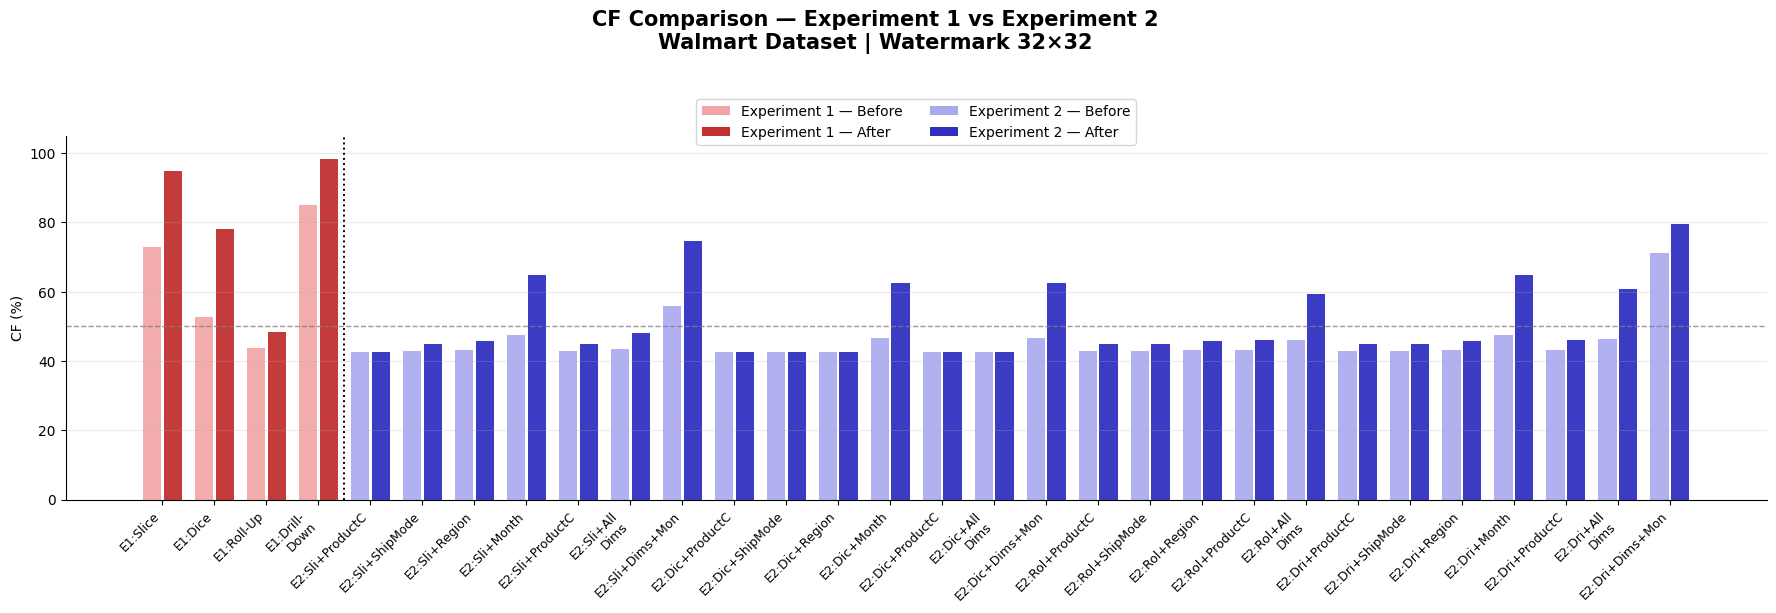

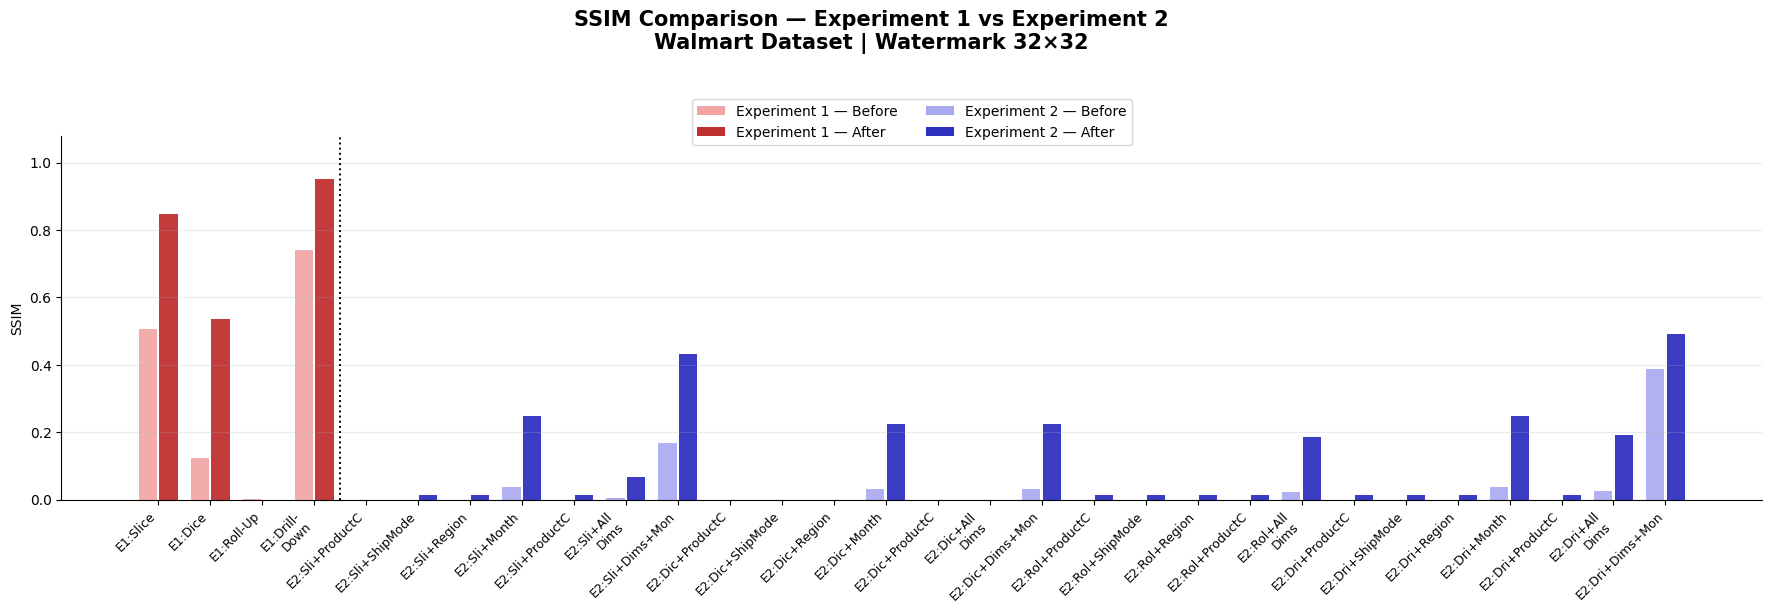

✅ Saved: exp1_vs_exp2_CF_HDHI.png and exp1_vs_exp2_SSIM_HDHI.png


In [14]:
# ── CELL 13 — Experiment 1 vs Experiment 2 Comparison ───────────────────────
best_exp1 = exp1_df.loc[exp1_df['CF After %'].idxmax()]
best_exp2 = exp2_df.loc[exp2_df['CF After %'].idxmax()]

print("═"*70)
print("  COMPARISON: Experiment 1 vs Experiment 2")
print("  Dataset: Walmart Dataset")
print("═"*70)
print(f"\n  Best Exp 1 operation : {best_exp1['Operation']}")
print(f"    Rows in View : {best_exp1['Rows in View']}")
print(f"    CF After %   : {best_exp1['CF After %']:.4f}%")
print(f"    SSIM After   : {best_exp1['SSIM After']:.6f}")
print(f"    Quality      : {best_exp1['Quality']}")
print(f"\n  Best Exp 2 config    : {best_exp2['OLAP Operation']} + {best_exp2['GROUP BY Config']}")
print(f"    Distinct Groups : {best_exp2['Distinct Groups']}")
print(f"    CF After %   : {best_exp2['CF After %']:.4f}%")
print(f"    SSIM After   : {best_exp2['SSIM After']:.6f}")
print(f"    Quality      : {best_exp2['Quality']}")

delta_cf   = best_exp2['CF After %']  - best_exp1['CF After %']
delta_ssim = best_exp2['SSIM After']  - best_exp1['SSIM After']
print(f"\n  ΔCF (Exp2 − Exp1)   : {delta_cf:+.4f}%")
print(f"  ΔSSIM (Exp2 − Exp1) : {delta_ssim:+.6f}")
verdict = ("✅ Experiment 2 outperforms Experiment 1"
           if delta_cf > 0 else "⚠️  Experiment 1 outperforms Experiment 2")
print(f"\n  → {verdict}")
print("═"*70)

# ── Prepare labels and values ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import textwrap

def wrap_labels(labels, width=11):
    return [textwrap.fill(str(l), width=width, break_long_words=False) for l in labels]

exp1_labels = [f"E1:{r}" for r in exp1_df['Operation']]
exp2_labels = [
    f"E2:{r['OLAP Operation'][:3]}+{r['GROUP BY Config'].split(':')[-1].strip()[:8]}"
    for _, r in exp2_df.iterrows()
]

all_labels = exp1_labels + exp2_labels
x = np.arange(len(all_labels))
wrapped_labels = wrap_labels(all_labels, width=11)

all_cf_b    = list(exp1_df['CF Before %'])  + list(exp2_df['CF Before %'])
all_cf_a    = list(exp1_df['CF After %'])   + list(exp2_df['CF After %'])
all_ssim_b  = list(exp1_df['SSIM Before'])  + list(exp2_df['SSIM Before'])
all_ssim_a  = list(exp1_df['SSIM After'])   + list(exp2_df['SSIM After'])

# Paper-friendly colors
exp1_before = '#f2a3a3'   # light red
exp1_after  = '#c03030'   # dark red
exp2_before = '#a9a9f0'   # light blue
exp2_after  = '#3030c0'   # dark blue

colors_before = [exp1_before] * len(exp1_df) + [exp2_before] * len(exp2_df)
colors_after  = [exp1_after]  * len(exp1_df) + [exp2_after]  * len(exp2_df)

legend_handles = [
    Patch(facecolor=exp1_before, edgecolor='none', label='Experiment 1 — Before'),
    Patch(facecolor=exp1_after,  edgecolor='none', label='Experiment 1 — After'),
    Patch(facecolor=exp2_before, edgecolor='none', label='Experiment 2 — Before'),
    Patch(facecolor=exp2_after,  edgecolor='none', label='Experiment 2 — After'),
]

# ── CF Figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle(
    'CF Comparison — Experiment 1 vs Experiment 2\n'
    f'Walmart Dataset | Watermark {WM_SIZE}×{WM_SIZE}',
    fontsize=15, fontweight='bold', y=0.98
)

ax.bar(x - 0.2, all_cf_b, width=0.35, color=colors_before, alpha=0.90)
ax.bar(x + 0.2, all_cf_a, width=0.35, color=colors_after,  alpha=0.95)

ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('CF (%)')
ax.set_ylim(0, 105)
ax.axhline(50, color='gray', linestyle='--', lw=1, alpha=0.8)
ax.axvline(len(exp1_df) - 0.5, color='black', linestyle=':', lw=1.4)
ax.grid(True, axis='y', alpha=0.25)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=True,
    fontsize=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.80, bottom=0.28, left=0.05, right=0.995)
fig.savefig('exp1_vs_exp2_CF_walmart.png', dpi=300, bbox_inches='tight')
plt.show()

# ── SSIM Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle(
    'SSIM Comparison — Experiment 1 vs Experiment 2\n'
    f'Walmart Dataset | Watermark {WM_SIZE}×{WM_SIZE}',
    fontsize=15, fontweight='bold', y=0.98
)

ax.bar(x - 0.2, all_ssim_b, width=0.35, color=colors_before, alpha=0.90)
ax.bar(x + 0.2, all_ssim_a, width=0.35, color=colors_after,  alpha=0.95)

ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('SSIM')
ax.set_ylim(0, 1.08)
ax.axvline(len(exp1_df) - 0.5, color='black', linestyle=':', lw=1.4)
ax.grid(True, axis='y', alpha=0.25)

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=True,
    fontsize=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.80, bottom=0.28, left=0.05, right=0.995)
fig.savefig('exp1_vs_exp2_SSIM_walmart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: exp1_vs_exp2_CF_HDHI.png and exp1_vs_exp2_SSIM_HDHI.png")

In [ ]:
# ── CELL 14 — Full Text Report ───────────────────────────────────────────────

lines = [
    "=" * 75,
    "  IBW WATERMARKING — OLAP ROBUSTNESS EXPERIMENTS",
    "  Sardroudi & Ibrahim (2010) | Walmart Retail Sales Dataset",
    "=" * 75,
    "",
    f"  Dataset         : Walmart Retail Sales ({len(df_original)} rows)",
    f"  SECRET_KEY      : {SECRET_KEY}",
    f"  F / NUM_LSB / NUM_MSB : {F} / {NUM_LSB} / {NUM_MSB}",
    f"  Fixed WM Size   : {WM_SIZE}×{WM_SIZE} = {WM_SIZE**2} pixels",
    f"  Eligible rows   : {len(ELIGIBLE_PKS)}",
    f"  Measure columns : {', '.join(MEASURE_COLS)}",
    "",
    "─" * 75,
    "  EXPERIMENT 1 — Global Embedding → OLAP → Extract",
    "─" * 75,
    f"  {'Operation':<15} | {'Rows':>6} | {'Cov%':>6} | {'CF_bef':>8} | {'CF_aft':>8} | {'SSIM_b':>8} | {'SSIM_a':>8} | {'Quality'}",
    "-" * 90,
] + [
    f"  {r['Operation']:<15} | {r['Rows in View']:>6} | {r['Coverage %']:>5.2f}% | "
    f"{r['CF Before %']:>7.4f}% | {r['CF After %']:>7.4f}% | "
    f"{r['SSIM Before']:>8.6f} | {r['SSIM After']:>8.6f} | {r['Quality']}"
    for _, r in exp1_df.iterrows()
] + [
    "",
    "─" * 75,
    "  EXPERIMENT 2 — OLAP Operation → GROUP BY → Group-wise Embedding → Extract",
    "─" * 75,
    f"  {'OLAP Op':<12} | {'GROUP BY Config':<28} | {'Groups':>6} | {'Cov%':>6} | {'CF_bef':>8} | {'CF_aft':>8} | {'SSIM_b':>8} | {'SSIM_a':>8} | {'Quality'}",
    "-" * 120,
] + [
    f"  {r['OLAP Operation']:<12} | {r['GROUP BY Config']:<28} | {r['Distinct Groups']:>6} | {r['Coverage %']:>5.2f}% | "
    f"{r['CF Before %']:>7.4f}% | {r['CF After %']:>7.4f}% | "
    f"{r['SSIM Before']:>8.6f} | {r['SSIM After']:>8.6f} | {r['Quality']}"
    for _, r in exp2_df.iterrows()
] + [
    "",
    "─" * 75,
    "  CARDINALITY EFFECT (Experiment 2 Key Finding)",
    "─" * 75,
    f"  Overall Pearson r (Distinct Groups ↔ CF After %) = {exp2_df['Distinct Groups'].corr(exp2_df['CF After %']):.4f}",
    "",
    "─" * 75,
    "  CONCLUSION",
    "─" * 75,
    f"  Best Exp 1 : {best_exp1['Operation']} → CF={best_exp1['CF After %']:.4f}% | SSIM={best_exp1['SSIM After']:.6f}",
    f"  Best Exp 2 : {best_exp2['OLAP Operation']} + {best_exp2['GROUP BY Config']} → CF={best_exp2['CF After %']:.4f}% | SSIM={best_exp2['SSIM After']:.6f}",
    f"  ΔCF (Exp2−Exp1) = {delta_cf:+.4f}%",
    f"  → {verdict}",
    "",
    "=" * 75,
]

report = "\n".join(lines)
print(report)
with open('olap_watermark_walmart_report.txt', 'w') as f:
    f.write(report)
print("\n✅ olap_watermark_walmart_report.txt saved")

  IBW WATERMARKING — OLAP ROBUSTNESS EXPERIMENTS
  Sardroudi & Ibrahim (2010) | Walmart Retail Sales Dataset

  Dataset         : Walmart Retail Sales (8399 rows)
  SECRET_KEY      : walmart_ibw_2024
  F / NUM_LSB / NUM_MSB : 5 / 4 / 2
  Fixed WM Size   : 32×32 = 1024 pixels
  Eligible rows   : 1322
  Measure columns : Sales, Profit, UnitPrice, ShippingCost

───────────────────────────────────────────────────────────────────────────
  EXPERIMENT 1 — Global Embedding → OLAP → Extract
───────────────────────────────────────────────────────────────────────────
  Operation       |   Rows |   Cov% |   CF_bef |   CF_aft |   SSIM_b |   SSIM_a | Quality
------------------------------------------------------------------------------------------
  Slice           |   4610 | 51.95% | 62.2070% | 95.4102% | 0.329250 | 0.786149 | Good
  Dice            |   1250 | 18.75% | 36.9141% | 81.0547% | 0.088523 | 0.321380 | Poor
  Roll-Up         |   1351 | 18.07% | 26.8555% | 47.4609% | -0.002672 | 0.015157 

In [ ]:
# ── CELL 15 — Download All Outputs ──────────────────────────────────────────
output_files = [
    'original_walmart.csv',
    'watermarked_walmart_global.csv',
    'experiment1_results.csv',
    'experiment2_results.csv',
    'olap_watermark_walmart_report.txt',
    'watermark_original.png',
    'exp1_cf_ssim_summary.png',
    'exp1_watermark_grid.png',
    'exp2_summary_plots.png',
    'exp2_watermark_grid.png',
    'exp1_vs_exp2_comparison.png',
    'exp2_cardinality_vs_cf.png',
]

for fname in output_files:
    try:
        files.download(fname)
        print(f"✅ {fname}")
    except Exception as e:
        print(f"⚠️  {fname} — {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ original_walmart.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ exp2_watermark_grid.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ exp1_vs_exp2_comparison.png
⚠️  exp2_cardinality_vs_cf.png — Cannot find file: exp2_cardinality_vs_cf.png
